# Phân tích Yếu tố Tài chính và Tác động đến Chất lượng Cuộc sống

Mục tiêu của Notebook này là xem xét tác động của thu nhập đến sức khỏe của người lao động, đồng thời phân tích sự chênh lệch mức lương trung bình giữa các hình thức làm việc và giới tính.

In [12]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [13]:
df = load_raw_data()
df_clean = get_da_data(df)
sns.set_theme(style='whitegrid')

In [14]:
display(df_clean[['Salary_Range', 'Salary_Midpoint']].head())

,Salary_Range,Salary_Midpoint
0,$40K-60K,50000
1,$80K-100K,90000
2,$80K-100K,90000
3,$60K-80K,70000
4,$60K-80K,70000


## 1. Mối liên hệ giữa Mức lương và Mức độ Kiệt sức (Burnout) / Sức khỏe tinh thần

**Câu hỏi phân tích:** * Mức lương cao có thực sự giúp giảm bớt tỷ lệ kiệt sức (Burnout) và cải thiện sức khỏe tinh thần (có thể do tiếp cận dịch vụ y tế tốt hơn)? 
* Hay ngược lại, thu nhập cao lại đi kèm với mức độ trầm cảm cao hơn và áp lực công việc khổng lồ?

C:\Users\HPC\AppData\Local\Temp\ipykernel_8284\3686043972.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=x_col, y='Salary_Midpoint',
C:\Users\HPC\AppData\Local\Temp\ipykernel_8284\3686043972.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=x_col, y='Salary_Midpoint',


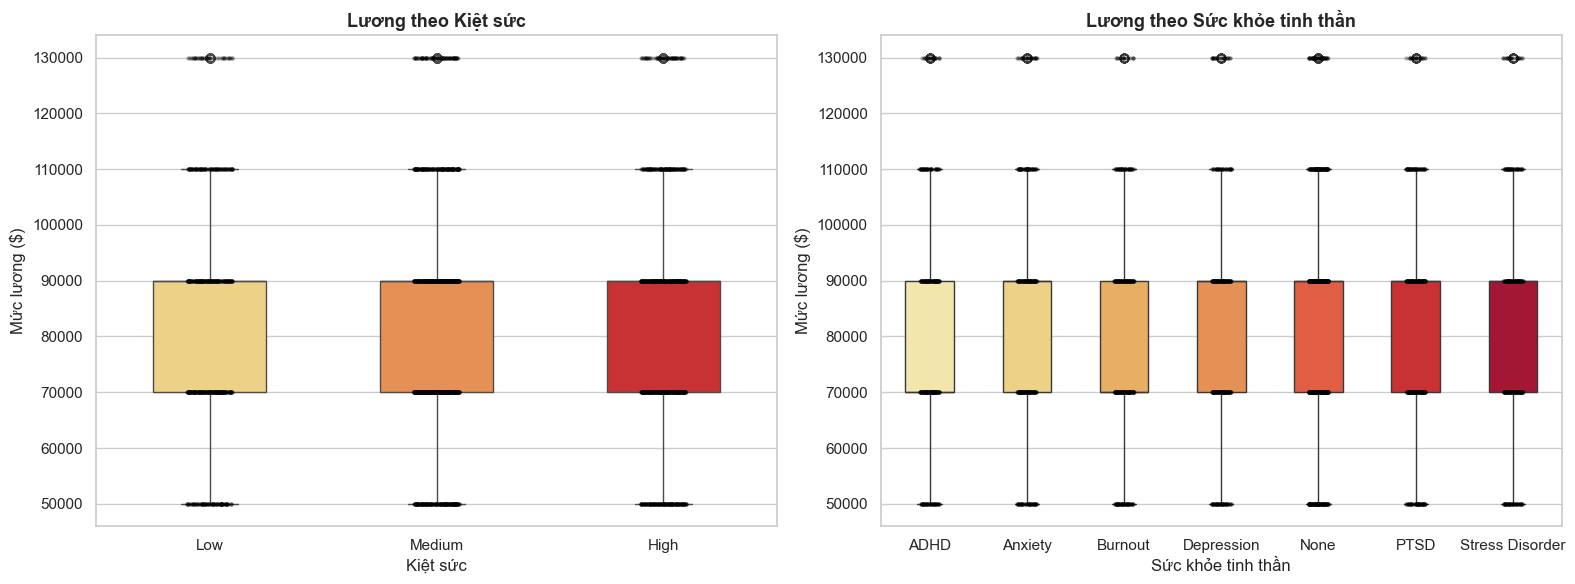

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, x_col, title in zip(
    axes,
    ['Burnout_Level', 'Mental_Health_Status'],
    ['Kiệt sức', 'Sức khỏe tinh thần']
):
    sns.boxplot(data=df_clean, x=x_col, y='Salary_Midpoint',
                order=['Low','Medium','High'] if x_col=='Burnout_Level' else None,
                palette='YlOrRd', ax=ax, width=0.5)
    sns.stripplot(data=df_clean, x=x_col, y='Salary_Midpoint',
                  order=['Low','Medium','High'] if x_col=='Burnout_Level' else None,
                  color='black', alpha=0.3, size=3, ax=ax)  # thấy phân bố thực tế
    ax.set_title(f'Lương theo {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Mức lương ($)')

plt.tight_layout()
plt.show()

In [16]:
from scipy import stats

# Tách lương theo từng nhóm burnout
low    = df_clean[df_clean['Burnout_Level'] == 'Low']['Salary_Midpoint']
medium = df_clean[df_clean['Burnout_Level'] == 'Medium']['Salary_Midpoint']
high   = df_clean[df_clean['Burnout_Level'] == 'High']['Salary_Midpoint']

# ANOVA test — kiểm định xem 3 nhóm có khác nhau thực sự không
f_stat, p_value = stats.f_oneway(low, medium, high)
print(f"ANOVA — F: {f_stat:.3f} | p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Có sự khác biệt có ý nghĩa thống kê về lương giữa các nhóm burnout")
else:
    print("❌ Không có sự khác biệt có ý nghĩa — lương có thể không phải yếu tố chính")

# Thống kê mô tả từng nhóm
print("\n--- Lương trung bình theo nhóm ---")
print(df_clean.groupby('Burnout_Level')['Salary_Midpoint'].agg(['mean','median','std']).round(0))

ANOVA — F: 0.062 | p-value: 0.9399
❌ Không có sự khác biệt có ý nghĩa — lương có thể không phải yếu tố chính

--- Lương trung bình theo nhóm ---
                  mean   median      std
Burnout_Level                           
Low            82752.0  90000.0  21704.0
Medium         82796.0  90000.0  22351.0
High           82486.0  90000.0  22727.0


In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Encode Burnout_Level
le = LabelEncoder()
df_model = df_clean[['Salary_Midpoint', 'Burnout_Level']].dropna()
df_model['Burnout_encoded'] = le.fit_transform(df_model['Burnout_Level'])

X = df_model[['Salary_Midpoint']]
y = df_model['Burnout_encoded']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(f"Hệ số lương: {model.coef_[0][0]:.6f}")
print(f"Accuracy: {model.score(X, y):.2%}")
print(f"Classes: {le.classes_}")

Hệ số lương: 0.000000
Accuracy: 43.27%
Classes: ['High' 'Low' 'Medium']


**Nhận xét: Mức lương & Sức khỏe Tinh thần**
* Kết quả kiểm định ANOVA (F = 0.062, p = 0.94) cho thấy không có sự khác biệt có ý nghĩa thống kê về mức lương giữa các nhóm kiệt sức (Low/Medium/High) — cả ba nhóm đều có median = $90,000 và mean dao động rất nhỏ (~$82,500–$82,800).
* Tương tự, biểu đồ phân phối lương theo từng tình trạng sức khỏe tinh thần (ADHD, Anxiety, Depression, PTSD, Stress Disorder...) cũng không cho thấy sự phân hóa rõ ràng. Mô hình phân loại chỉ đạt accuracy 43.27% với hệ số lương = 0 — xác nhận lương không có khả năng dự đoán mức độ kiệt sức.

 Lương cao không bảo vệ nhân viên khỏi kiệt sức hay bệnh lý tinh thần — cần xem xét các yếu tố khác như môi trường làm việc, khối lượng công việc và hỗ trợ tâm lý.

## 2. Chênh lệch Mức lương theo Hình thức làm việc và Ngành nghề

**Câu hỏi phân tích:** Mức lương trung bình (Salary_Midpoint) có sự chênh lệch như thế nào giữa nhóm làm việc Remote và nhóm Onsite trong cùng một ngành nghề?

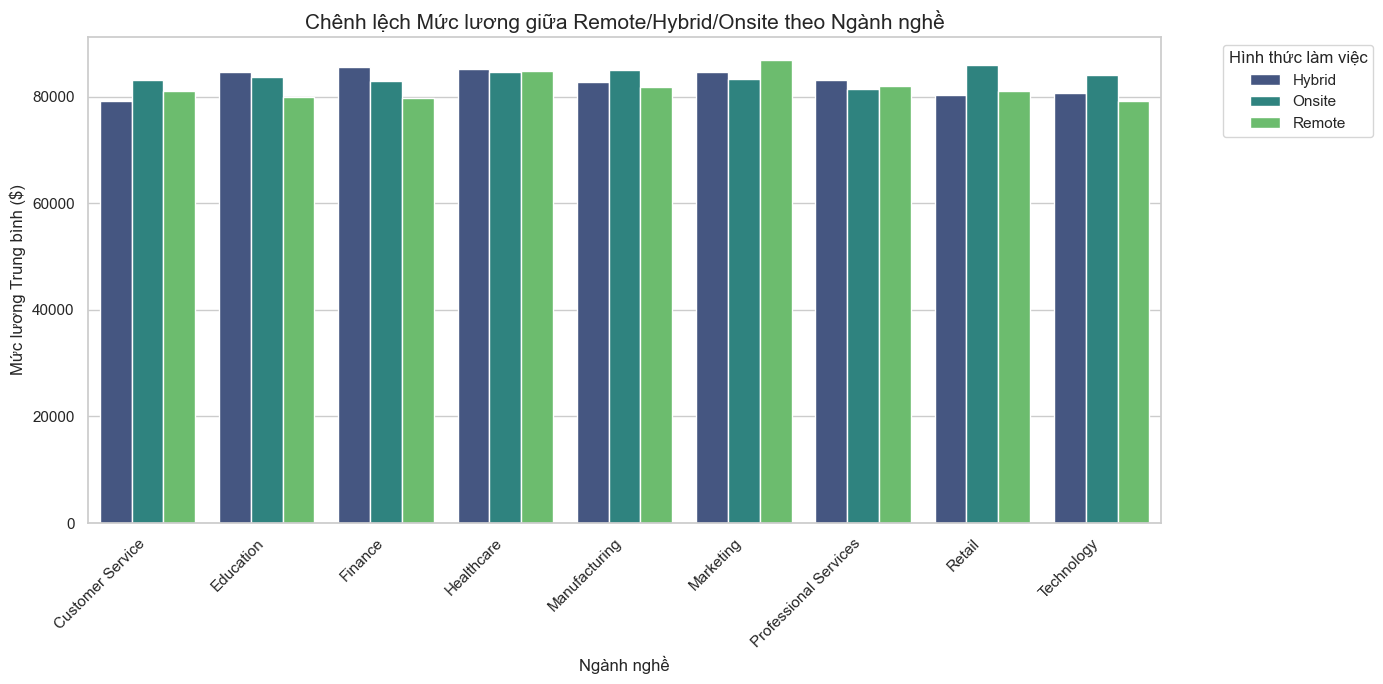

In [18]:
plt.figure(figsize=(14, 7))

# So sánh lương giữa các hình thức làm việc phân tách theo ngành nghề
sns.barplot(data=df_clean, x='Industry', y='Salary_Midpoint', hue='Work_Arrangement', palette='viridis', errorbar=None)

plt.title('Chênh lệch Mức lương giữa Remote/Hybrid/Onsite theo Ngành nghề', fontsize=15)
plt.xlabel('Ngành nghề', fontsize=12)
plt.ylabel('Mức lương Trung bình ($)', fontsize=12)
plt.legend(title='Hình thức làm việc', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Nhận xét: Chênh lệch Mức lương giữa Remote / Hybrid / Onsite theo Ngành nghề**
* Biểu đồ cho thấy mức lương trung bình giữa 3 hình thức làm việc gần như không có sự chênh lệch đáng kể trong tất cả 9 ngành nghề, đều dao động quanh $80,000 – $87,000.
* Một vài điểm phân hóa nhỏ đáng chú ý: Marketing có Remote nhỉnh hơn (~$87,000), Retail có Onsite cao hơn đôi chút, trong khi Technology có Remote thấp hơn hai hình thức còn lại. Tuy nhiên, biên độ chênh lệch giữa các cột trong cùng một ngành không vượt quá ~$5,000–$7,000 — quá nhỏ để kết luận hình thức làm việc ảnh hưởng đến lương.

 Hình thức làm việc (Remote/Hybrid/Onsite) không tạo ra sự khác biệt lương có ý nghĩa trong bất kỳ ngành nào — mức lương được quyết định bởi các yếu tố khác như vị trí, kinh nghiệm hoặc ngành nghề, chứ không phải nơi làm việc.

## 3. Chênh lệch Thu nhập theo Giới tính (Gender Pay Gap)

**Câu hỏi phân tích:** Có tồn tại sự khác biệt nào về mức lương giữa Nam và Nữ khi làm cùng các hình thức làm việc giống nhau hay không?

In [23]:
df_clean['Gender'] = df_clean['Gender'].astype(str).replace({
    'Non-binary': 'Other',
    'Prefer not to say': 'Other'
})

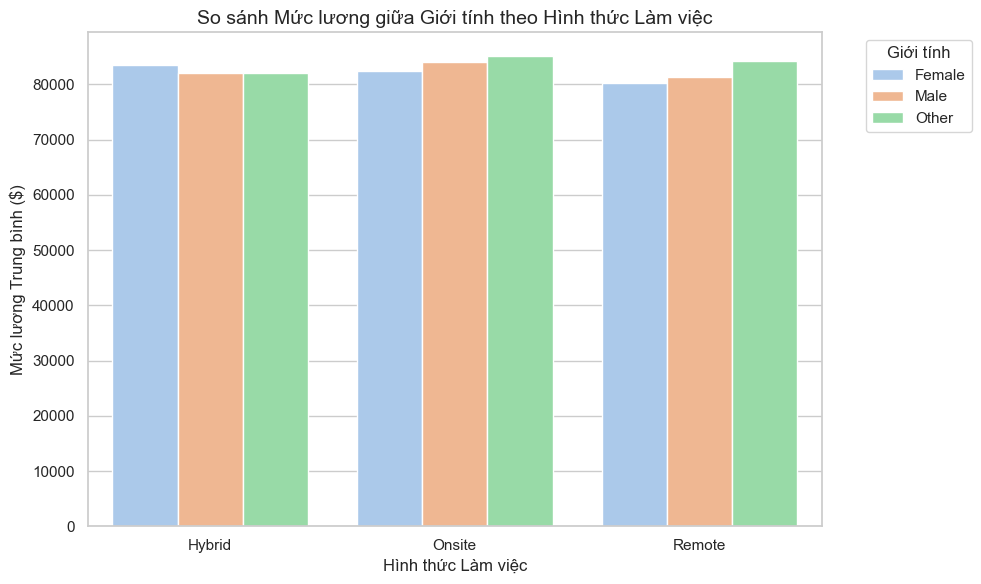

In [24]:
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Barplot so sánh lương giữa Nam/Nữ theo Hình thức làm việc
sns.barplot(data=df_clean, x='Work_Arrangement', y='Salary_Midpoint', hue='Gender', palette='pastel', errorbar=None)

plt.title('So sánh Mức lương giữa Giới tính theo Hình thức Làm việc', fontsize=14)
plt.xlabel('Hình thức Làm việc', fontsize=12)
plt.ylabel('Mức lương Trung bình ($)', fontsize=12)
plt.legend(title='Giới tính', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Nhận xét: Chênh lệch Thu nhập theo Giới tính (Gender Pay Gap)**
* Biểu đồ so sánh mức lương trung bình giữa 3 giới tính (Female, Male, Other) trong từng hình thức làm việc, kết quả cho thấy chênh lệch rất nhỏ, toàn bộ dao động trong khoảng $80,000 – $85,000.
* Điểm đáng chú ý: ở Hybrid, Female nhỉnh hơn đôi chút (~$83,000 vs ~$82,000); sang Onsite và Remote, Male và Other lại cao hơn Female một chút — tuy nhiên biên độ chênh lệch không vượt quá ~$4,000–$5,000 trong mọi trường hợp. Đặc biệt, nhóm Remote – Female có mức lương thấp nhất (~$80,000), trong khi Onsite/Remote – Other cao nhất (~$84,000–$85,000).

 Không tồn tại Gender Pay Gap rõ ràng trong tập dữ liệu này — mức lương giữa Nam, Nữ và Other gần như ngang bằng nhau ở cả 3 hình thức làm việc. Sự chênh lệch nhỏ quan sát được có thể do biến động ngẫu nhiên hơn là bất bình đẳng có hệ thống.

## Tổng kết

**Nhận xét:** Tác động Tài chính (Financial Impact)Tác động Tài chính (Financial Impact)
* Phân tích tổng hợp từ 3 góc độ — hình thức làm việc, sức khỏe tinh thần và giới tính — đều dẫn đến cùng một kết luận nhất quán: mức lương không phải yếu tố phân hóa trong tập dữ liệu này.
* Cụ thể, kiểm định ANOVA (F = 0.062, p = 0.94) xác nhận không có sự khác biệt có ý nghĩa thống kê về lương giữa các nhóm kiệt sức; mô hình phân loại chỉ đạt accuracy 43.27% với hệ số lương = 0. Tương tự, dù so sánh theo ngành nghề (~$80,000–$87,000), theo hình thức làm việc hay theo giới tính, biên độ chênh lệch đều không vượt quá $5,000–$7,000 — quá nhỏ để có ý nghĩa thực tiễn.

 Lương không phải nguyên nhân, cũng không phải giải pháp cho các vấn đề sức khỏe và kiệt sức tại nơi làm việc. Tăng lương đơn thuần không đủ để cải thiện wellbeing nhân viên — tổ chức cần đầu tư vào các yếu tố phi tài chính như môi trường làm việc, khối lượng công việc hợp lý, hỗ trợ tâm lý và tính linh hoạt trong công việc để tạo ra tác động thực sự.